### Importing The Python Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the Dataset 

In [2]:
df=pd.read_csv('messy_customer_sales_data.csv')

In [3]:
df

,Customer_ID,Name,Gender,Age,City,Signup_Date,Last_Purchase_Date,Purchase_Amount,Feedback_Score,Email
0,CUST10468,George Wright,MALE,51.0,Hyderabad,2020-09-16,2025-11-07,62303.7,3.0,wright82@example.com
1,CUST6922,Robert Gonzalez,m,55.0,Surat,2020-08-13,2023-04-27,NaN,8.0,robertgonzalez@yahoo.com
2,CUST9728,Joseph Martin,female,47.0,Hyderabad,2022-08-03,2024-06-24,31636.7,3.0,jmartin@gmail.com
3,CUST2674,Anthony King,male,31.0,ahmedabad,2023-11-03,2024-09-12,77309.3,4.0,aking@hotmail.com
4,CUST3643,Matthew Taylor,f,46 years,JAIPUR,2022-12-06,2024-11-25,6543.9,8.0,taylor26@hotmail.com
...,...,...,...,...,...,...,...,...,...,...
10395,CUST5999,Brenda Thomas,FEMALE,53.0,pune,2023-03-12,2024-01-24,73908.6,3.0,brendathomas@outlook.com
10396,CUST5694,Joseph Hall,FEMALE,65.0,nagpur,2020-03-07,2023-08-19,17528.9,3.0,hall17@outlook.com
10397,CUST3598,James Martinez,Female,44.0,PUNE,2021-04-09,2025-10-09,44650.6,2.0,martinez86@example.com
10398,CUST5352,Mary Pierce,f,54.0,Hyderabad,2020-12-02,2023-07-21,66360.6,10.0,marypierce@outlook.com


In [4]:
pd.set_option('display.float_format','{:.2f}'.format)

### Quick Overview of the Dataset 

In [5]:
def audit(df):
    summary=pd.DataFrame({
        'Dtype':df.dtypes,
        'Null_Values':df.isnull().sum(),
        'Null_values_%':(df.isnull().mean()*100).round(2),
        'Unique':df.nunique(),
        'Unique_%':(df.nunique() / len(df)*100).round(2)
    })
    return summary

audit(df)

,Dtype,Null_Values,Null_values_%,Unique,Unique_%
Customer_ID,object,0,0.00,6390,61.44
Name,object,504,4.85,2558,24.60
Gender,object,495,4.76,10,0.10
Age,object,756,7.27,106,1.02
City,object,742,7.13,32,0.31
Signup_Date,object,0,0.00,2167,20.84
Last_Purchase_Date,object,591,5.68,1095,10.53
Purchase_Amount,float64,652,6.27,9488,91.23
Feedback_Score,float64,509,4.89,10,0.10
Email,object,655,6.30,8021,77.12


### After the Quick overview of the dataset 
### Filled the Name & Email Column with "Not Available" to ensure the consistency and clearly identify the records with unavailable customer Names & Emails.

In [6]:
df['Name']=df['Name'].fillna('N/A')

In [7]:
df['Email']=df['Email'].fillna('N/A')

### Found 368 missing entries in the Name Column.

In [8]:
df[df['Name']=='N/A'].value_counts().sum()

np.int64(368)

### Identified 437 missing entries in the Email Column.

In [9]:
df[df['Email']=='N/A'].value_counts().sum()

np.int64(437)

### Then formated "Last_Purchase_Date" column into datetime data type.

#### Retained the missing values (NaT) to preserve data integrity, as assigning an artifical date could lead to misleading analysis.

In [10]:
df['Last_Purchase_Date']=pd.to_datetime(df['Last_Purchase_Date'])

In [11]:
df['Last_Purchase_Date'].isnull().sum()

np.int64(591)

#### Extracted the numeric values from Age Column using regular expressions (re) and filled using the median to preserve the data distribution and minimize the impact of outliers, then finally converted the values into numeric format for further analysis.

In [12]:
import re 

def extract_age(age):
    age_num=re.findall(r'\d+',str(age))
    if len(age_num)>0:
        return int(age_num[0])
    else :
        return None 

df['Age']=df['Age'].apply(extract_age)

In [13]:
df.loc[4:500,'Age']

4     46.00
5     60.00
6     51.00
7     20.00
8     26.00
       ... 
496   70.00
497   18.00
498   23.00
499   39.00
500   50.00
Name: Age, Length: 497, dtype: float64

In [14]:
df['Age']=df['Age'].fillna(df['Age'].median())

In [15]:
df['Age']=df['Age'].astype(int)

In [16]:
df.loc[5:500,'Age']

5      60
6      51
7      20
8      26
9      45
       ..
496    70
497    18
498    23
499    39
500    50
Name: Age, Length: 496, dtype: int64

### Formatting the inconsistent Gender column into a consistent , formatted and structure type for upcoming analysis.

In [17]:
df['Gender']=df['Gender'].str.lower()

In [18]:
df['Gender']=df['Gender'].replace({'m':'Male','f':'Female','female':'Female','male':'Male'})

In [19]:
df['Gender'].nunique()

2

In [20]:
df.isnull().sum()

Customer_ID             0
Name                    0
Gender                495
Age                     0
City                  742
Signup_Date             0
Last_Purchase_Date    591
Purchase_Amount       652
Feedback_Score        509
Email                   0
dtype: int64

#### Formatting the Categorial Data columns with Mode for data distribution and maintain consistency,
#### Numerical Data column with Median for minimizing the impact of outliers.

In [21]:
df['Gender']=df['Gender'].fillna(df['Gender'].mode()[0])

In [22]:
df['City']=df['City'].str.lower()

In [23]:
df['City']=df['City'].fillna(df['City'].mode()[0])

In [24]:
df['Purchase_Amount']=df['Purchase_Amount'].fillna(df['Purchase_Amount'].median())

In [25]:
df['Feedback_Score']=df['Feedback_Score'].fillna(df.groupby('Gender')['Feedback_Score'].transform('median'))

In [26]:
df['Signup_Date']=pd.to_datetime(df['Signup_Date'])

#### Ensuring each column was assigned the appropriate data type for accurate analysis.

In [27]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10400 entries, 0 to 10399
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   Customer_ID         10400 non-null  object        
 1   Name                10400 non-null  object        
 2   Gender              10400 non-null  object        
 3   Age                 10400 non-null  int64         
 4   City                10400 non-null  object        
 5   Signup_Date         10400 non-null  datetime64[ns]
 6   Last_Purchase_Date  9809 non-null   datetime64[ns]
 7   Purchase_Amount     10400 non-null  float64       
 8   Feedback_Score      10400 non-null  float64       
 9   Email               10400 non-null  object        
dtypes: datetime64[ns](2), float64(2), int64(1), object(5)
memory usage: 812.6+ KB


#### Removed duplicate records from the dataset to eliminate the redundant entries and improve  data quality, then reset the index to maintain a clean and sequential row order.

In [28]:
df.drop_duplicates(inplace=True)

In [29]:
df=df.reset_index(drop=True)

#### 203 duplicate records were removed.

In [30]:
df.shape

(10197, 10)

#### Performed outlier detection on Age,Purchase_Amount and Feedback_Score columns using box plots. No significant outliers were identified in these numerical features.

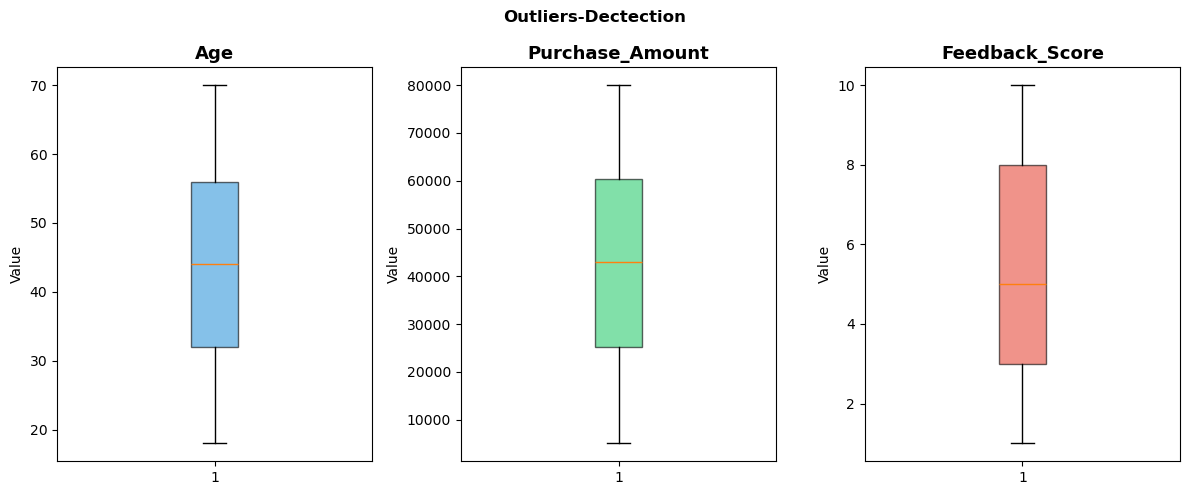

In [31]:
fig,axes=plt.subplots(1,3,figsize=(12,5))

columns=['Age','Purchase_Amount','Feedback_Score']
colors=['#3498db','#2ecc71','#e74c3c']

for ax,col,color in zip(axes,columns,colors):
    ax.boxplot(df[col].dropna(),patch_artist=True,boxprops=dict(facecolor=color,alpha=0.6))
    ax.set_title(f'{col}',fontsize=13,fontweight='bold')
    ax.set_ylabel('Value')
plt.suptitle('Outliers-Dectection',fontweight='bold')
plt.tight_layout()
plt.show()

#### KPI's based on Business Requiremnts.

In [32]:
Total_Sales = df['Purchase_Amount'].agg(['sum','max','min','mean','median'])
Total_Sales

sum      436083082.60
max          79997.70
min           5009.30
mean         42765.82
median       43003.90
Name: Purchase_Amount, dtype: float64

In [33]:
AvgOrderValue=df['Purchase_Amount'].mean().round(2)
print(f'The AvgOrderValue of the business is:{AvgOrderValue}')

The AvgOrderValue of the business is:42765.82


In [34]:
UniqueCustomer=df['Customer_ID'].nunique()
print(f'The Number of Unique Customers in business are {UniqueCustomer}')

The Number of Unique Customers in business are 6390


In [35]:
Repeated_Customers= (df['Customer_ID'].value_counts()>1).sum()
print(f'The Repeated or loyal Customers to the Business are {Repeated_Customers}')

The Repeated or loyal Customers to the Business are 2727


In [36]:
Avg_Sales = df['Purchase_Amount'].mean().round(2)
print(f'The Average Sales in Business is {Avg_Sales}')

The Average Sales in Business is 42765.82


In [37]:
df['Days_To_Last_Purchase']=(df['Last_Purchase_Date'] - df['Signup_Date']).dt.days
print('The Days Between the Last Purchase by the customers',df['Days_To_Last_Purchase'])

The Days Between the Last Purchase by the customers 0       1878.00
1        987.00
2        691.00
3        314.00
4        720.00
          ...  
10192    318.00
10193   1260.00
10194   1644.00
10195    961.00
10196   2098.00
Name: Days_To_Last_Purchase, Length: 10197, dtype: float64


In [38]:
Average_Gap =  df['Days_To_Last_Purchase'].mean().round()
print(f'The Average Gap of days for next Purchase by customer is {Average_Gap}')

The Average Gap of days for next Purchase by customer is 1277.0


In [59]:
monthly_Sales = df.groupby(df['Last_Purchase_Date'].dt.to_period('M'))['Purchase_Amount'].sum()

In [60]:
MOM_Growth = monthly_Sales.pct_change()*100
print(f'MOM Growth Rate in Business{MOM_Growth}.round(2)')

MOM Growth Rate in BusinessLast_Purchase_Date
2023-01      NaN
2023-02    -8.14
2023-03     3.81
2023-04   -12.73
2023-05    17.37
2023-06   -15.82
2023-07    14.58
2023-08     3.89
2023-09   -16.22
2023-10    24.18
2023-11    -5.72
2023-12    -7.52
2024-01     5.15
2024-02   -21.52
2024-03    19.07
2024-04     1.88
2024-05     3.49
2024-06    -6.67
2024-07   -13.00
2024-08    18.23
2024-09     0.37
2024-10    13.06
2024-11   -13.29
2024-12    15.65
2025-01   -11.43
2025-02   -15.82
2025-03    24.77
2025-04    -2.56
2025-05    -4.36
2025-06     2.09
2025-07    -1.70
2025-08     2.88
2025-09     2.49
2025-10    -5.70
2025-11     2.66
2025-12     4.47
Freq: M, Name: Purchase_Amount, dtype: float64.round(2)


In [56]:
yearly_Sales = df.groupby(df['Last_Purchase_Date'].dt.year)['Purchase_Amount'].sum()

In [58]:
YOY = yearly_Sales.pct_change()*100
print(f'YOY Growth Rate in Business{YOY}.round(2)')

YOY Growth Rate in BusinessLast_Purchase_Date
2023.00     NaN
2024.00   -4.63
2025.00    0.36
Name: Purchase_Amount, dtype: float64.round(2)


#### Segmented age column three equal-frequency group using pd.qcut() and label them as 'Young','Adult' and 'Senior'. A pie chart was created to visualize the distribution of customers across these age groups 

In [39]:
label=['Young','Adult','Senior']
df['Age_Group']=pd.qcut(df['Age'],q=3,labels=label)

#### The young Age group counted for the largest share of customers (34.5%), followed by senior (33.3%) and adult (32.3%). The distribution across all three age group was nearly balanced with only a small difference of 1-2% between them.

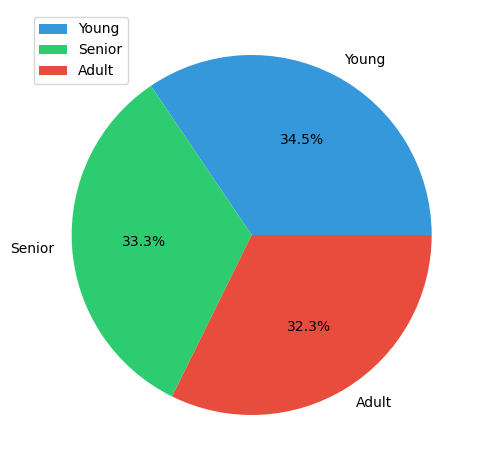

In [40]:
Gender_count=df['Age_Group'].value_counts()
colors=['#3498db','#2ecc71','#e74c3c']
plt.pie(Gender_count,colors=colors,autopct="%1.1f%%",labels=Gender_count.index)
plt.legend()
plt.tight_layout()
plt.show()

#### The bar chart was implemented on the Age groups and Young age group contributed the highest total purchases, followed by Senior and Adult age group.The contribution significantly to the overall revenue indicating the business has a well-balanced customer base , no single age group dominates the revenue.

C:\Users\Naveed Sultan\AppData\Local\Temp\ipykernel_13196\53518358.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  Total_Amount=df.groupby('Age_Group')['Purchase_Amount'].sum()/1000


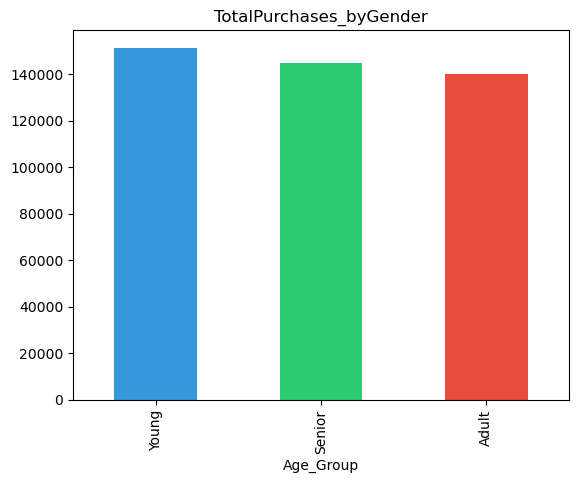

In [41]:
Total_Amount=df.groupby('Age_Group')['Purchase_Amount'].sum()/1000
Total_Amount.sort_values(ascending=False).plot(kind='bar',title='TotalPurchases_byGender',color=['#3498db','#2ecc71','#e74c3c'])
plt.show()

### The Horizontal Bar chart shows Chennai city recorded the highest total_purchase amount followed by the Pune city, on the other hand Lucknow had the lowest total purchase amount with Nagpur ranking just above it.

#### Their business should continue strengthening its present in high-performing city like Chennai and Pune, while investigating the lower sales in Lucknow and Nagpur. Targeted marketing campaign, Customer engagement initiatives or Promotional offers could help to improve the sales performance in these lower performing market.

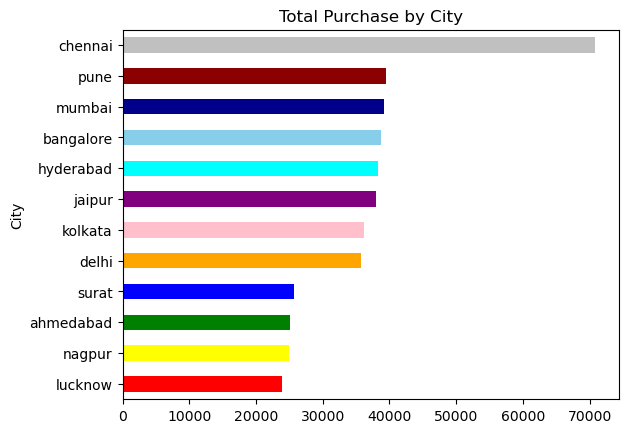

In [42]:
city_data=df.groupby('City')['Purchase_Amount'].sum()/1000
Color=['Red','Yellow','Green','Blue','Orange','Pink','Purple','cyan','skyblue','Darkblue','Darkred','Silver']
city_data.sort_values(ascending=True).plot(kind='barh',title="Total Purchase by City",color=Color)
plt.show()

### The line chart illustrates the total purchase amount trends across different age groups. The Young age group recorded the highest purchase amount, followed by the Senior group, while the adult age group recorded the lowest purchase amount.

#### The business should investigate why the Adult age group has the lower purchase_amount compared to Senior and Young , Overall taking necessary trategies that can help increase the purchase_amount among adult customers,while maintaining a strong performance of the  Young and the senior segments.

C:\Users\Naveed Sultan\AppData\Local\Temp\ipykernel_13196\2844271554.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  line_plot=df.groupby('Age_Group')['Purchase_Amount'].sum()/10000


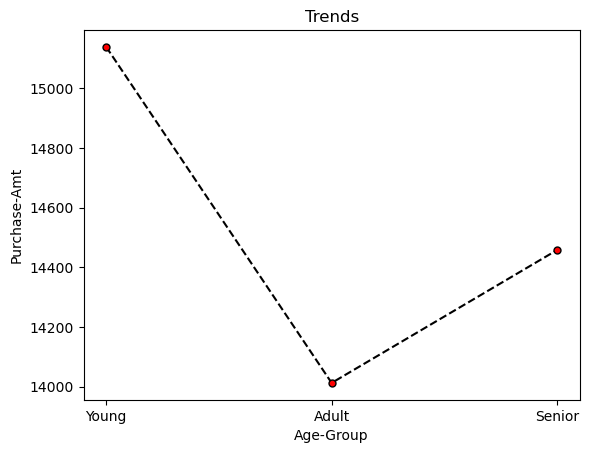

In [43]:
line_plot=df.groupby('Age_Group')['Purchase_Amount'].sum()/10000
line_style=dict(marker=".",markersize=10,markerfacecolor="Red",markeredgecolor="black",linestyle="dashed",color="black")
plt.plot(line_plot,**line_style)
plt.title("Trends")
plt.xlabel("Age-Group")
plt.ylabel("Purchase-Amt")
plt.show()

###  Three Plots together (Histogram + Boxplot + Density Plot).

#### The **Age-distribution** is balanced across the dataset with no significant outliers detected.Most customers fall within the middle-age range indicating that the business serves a diverse customer population across differengt age groups.

#### The **Purchase-Amount** is well distributed with no significant outliers, indicating the consistent customer spending patterns. Most customes make purchases within the moderate spending range suggesting the stable purchasing behavior.

#### The **Feedback_Scores** are evenly distributed with no significant outliers, indicating general consistent customer satisfaction level across the dataset reflecting a positive customer experience.

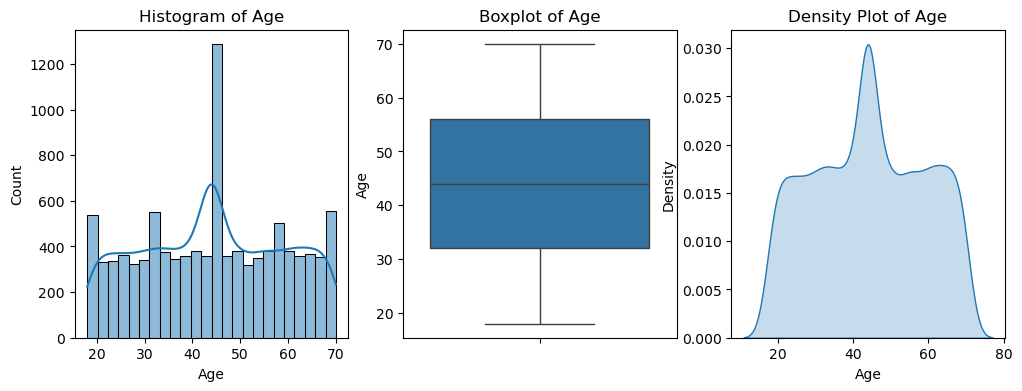

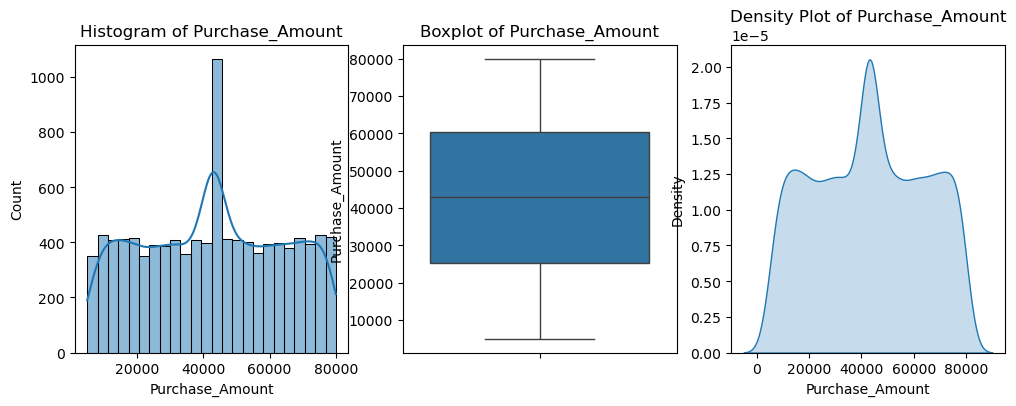

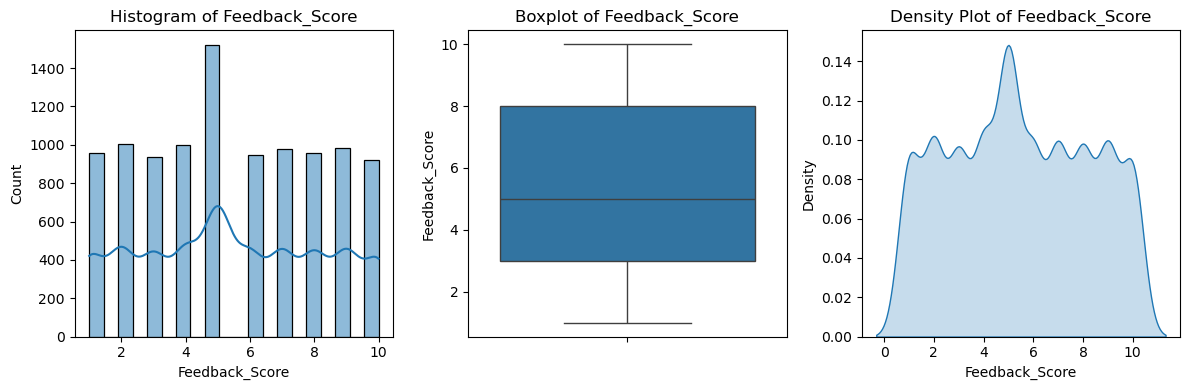

In [44]:
numeric_cols=['Age','Purchase_Amount','Feedback_Score']

for col in numeric_cols:
    plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    sns.histplot(df[col],kde=True)
    plt.title(f'Histogram of {col}')

    plt.subplot(1,3,2)
    sns.boxplot(df[col])
    plt.title(f'Boxplot of {col}')

    plt.subplot(1,3,3)
    sns.kdeplot(df[col],fill=True)
    plt.title(f'Density Plot of {col}')

plt.tight_layout()
plt.show()

#### The Clustered Bar chart compare the distribution of customers across different age group in each city.Chennai has the highest number of customers across the Young,Adult and Senior age groups.In contrast, Lucknow,Nagpur,Surat and Ahmedabad are comparatively fewer customers across all age groups.

<Axes: xlabel='City'>

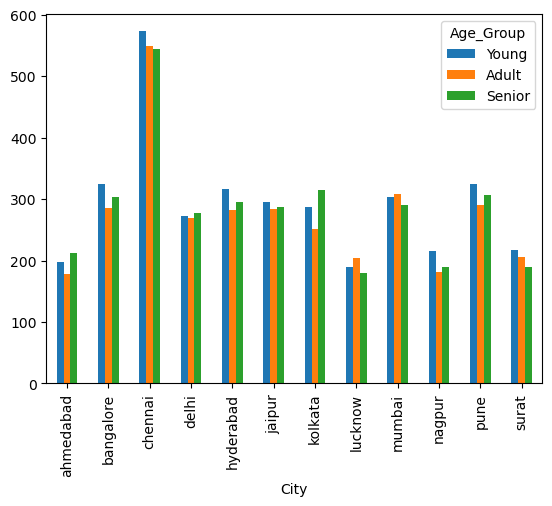

In [45]:
pd.crosstab(df['City'],df['Age_Group']).plot(kind='bar',stacked=False)

#### The Correlation Heatmap shows the relationship between Age,Purchase-Amount and feedback-Score, the correlation values are very close to zero indicating there is no strong positive or negative correlation between these variables.

<Axes: >

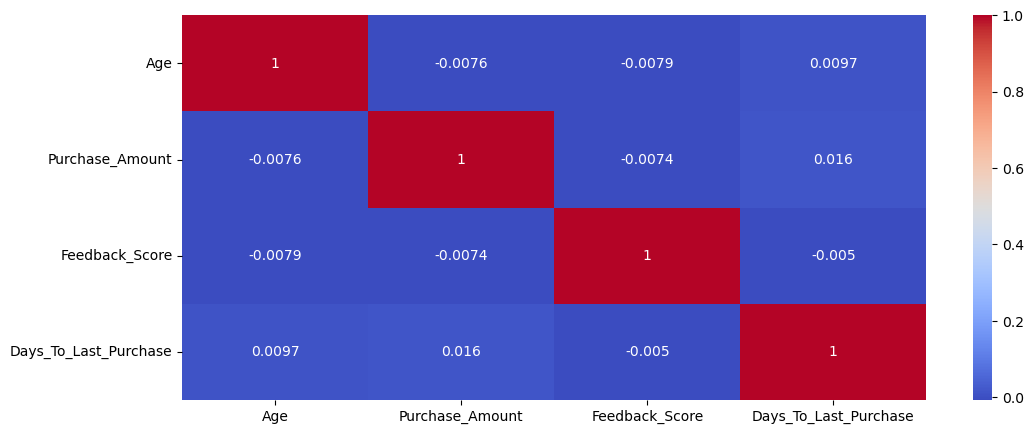

In [46]:
corr=df.corr(numeric_only=True)
fig,ax=plt.subplots(figsize=(12,5))

sns.heatmap(corr,annot=True,cmap='coolwarm')

#### The Box-plot compares the Age distribution across the young, Adult and Senior.Each age group falls within its expected age range with median ages increasing from Young to Adult to Senior. No significant outliers are observed indicating a well-segmented balanced dataset .

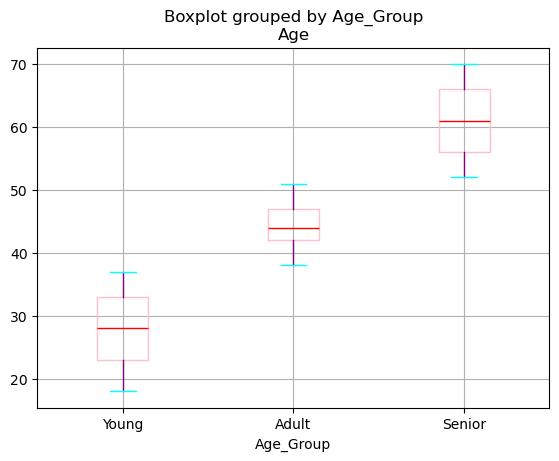

In [47]:
df.boxplot(column='Age',by='Age_Group',color=dict(boxes='pink',whiskers='purple',caps='cyan',medians='red'))
plt.show()

### The Dataset was successfully cleaned,transformed and prepared for analysis.EDA identify key customer trends across Age-group,Cities,Purchase-amount and Feedback-Scores.The Young Group and Chennai contributed the highest overall purchases. No significant outliers or strong correlations were found indicating a stable and reliable dataset the insights generated can support the customer segment targeted marketing and business decision-making.